# Importing Libraries

In [5]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model saving
import pickle

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

# Handling class imbalance
from imblearn.over_sampling import SMOTE

# Set visualization style
sns.set_style("whitegrid")

# 2. Load Dataset


In [6]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
pd.set_option("display.max_columns", None)

# Remove customerID as it's not useful for prediction
df.drop(columns=["customerID"], inplace=True)

print(f"Dataset shape: {df.shape}")

Dataset shape: (7043, 20)


# 3. Data Cleaning

In [7]:
# Identify numerical columns
nonCatCol = ["tenure", "MonthlyCharges", "TotalCharges"]

# Fix missing values in TotalCharges (spaces were present)
df = df.replace({" ": 0.0})
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
df["TotalCharges"] = df["TotalCharges"].fillna(0.0)

# Apply square root transformation to reduce skewness
df["TotalCharges"] = np.sqrt(df["TotalCharges"])

# 4. Exploratory Data Analysis

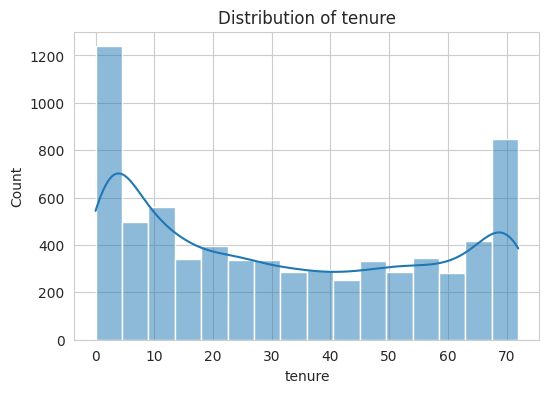

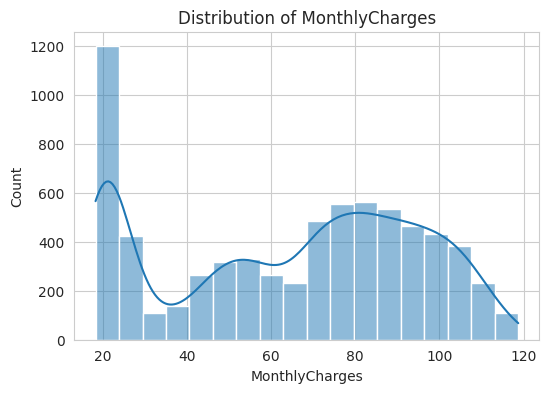

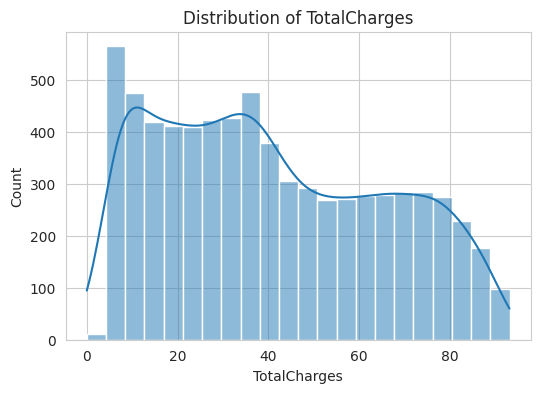

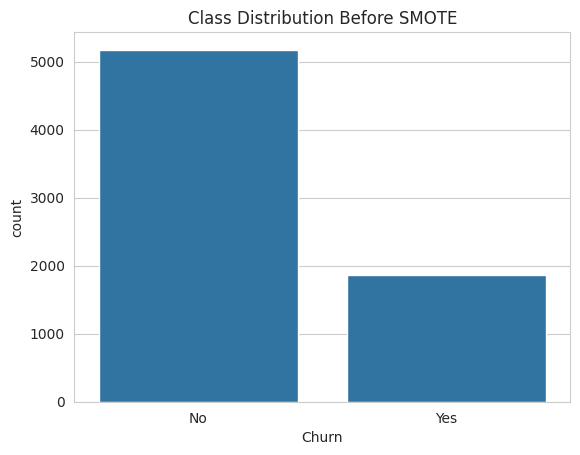

In [8]:
# Numerical features distribution
for col in nonCatCol:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

sns.countplot(x=df["Churn"])
plt.title("Class Distribution Before SMOTE")
plt.show()

# 5. Encode Categorical Variables

In [10]:
encoders = {}
for col in df.columns:
    if col not in nonCatCol:
        encoder = LabelEncoder()
        df[col] = encoder.fit_transform(df[col])
        encoders[col] = encoder

with open("encoders_data.pkl","wb") as f:
    pickle.dump(encoders,f)
with open("processed_data.csv","wb") as f:
    pickle.dump(df,f)

# 6. Train Test Split & SMOTE

In [ ]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_temp, y_train, y_temp = train_test_split(X,y,test_size=0.4,random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp,test_size=0.5,random_state=42)

print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f"\nOriginal class distribution:\n{y_train.value_counts().to_dict()}")
print(f"\nAfter SMOTE:\n{y_train_smote.value_counts().to_dict()}")

Train shape: (4225, 19)
Validation shape: (1409, 19)
Test shape: (1409, 19)

Original class distribution:
{0: 3105, 1: 1120}

After SMOTE:
{0: 3105, 1: 3105}


# 7. Scale Numerical Features For Logistic Regression

In [ ]:
X_train_log = X_train_smote.copy()
X_val_log = X_val.copy()
X_test_log = X_test.copy()

scalers = {}
for col in nonCatCol:
    scaler = StandardScaler()
    X_train_log[col] = scaler.fit_transform(X_train_log[[col]])
    X_val_log[col] = scaler.transform(X_val_log[[col]])
    X_test_log[col] = scaler.transform(X_test_log[[col]])
    scalers[col] = scaler

# Train Models

In [ ]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

cv_results = {}

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_smote, y_train_smote, cv=5, scoring='accuracy')
    cv_results[name] = cv_scores
    print(f"{name} - CV Accuracy: {cv_scores.mean()}")
    print(f"CV Standard Deviation: {cv_scores.std()}")


Decision Tree - CV Accuracy: 0.7824476650563608
CV Standard Deviation: 0.06174090283791314
Random Forest - CV Accuracy: 0.8441223832528181
CV Standard Deviation: 0.061927937184500875
XGBoost - CV Accuracy: 0.8293075684380031
CV Standard Deviation: 0.07674252592403044


# XGBoost & Logistic Regression

In [ ]:
# Train XGBoost (best from CV) on full training data
xgb_best = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_best.fit(X_train_smote, y_train_smote)

# Predictions
y_val_pred = xgb_best.predict(X_val)
y_test_pred = xgb_best.predict(X_test)

print(f"XGBoost Validation Accuracy: {accuracy_score(y_val, y_val_pred)}")
print(f"XGBoost Test Accuracy: {accuracy_score(y_test, y_test_pred)}")

# Save model
with open("XGB_final_model.pkl", "wb") as f:
    pickle.dump(xgb_best, f)


XGBoost Validation Accuracy: 0.7771469127040455
XGBoost Test Accuracy: 0.7735982966643009


# Logistic Regression for Revenue at Risk

In [ ]:
# Train logistic regression for probability predictions
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_log, y_train_smote)

# Get churn probabilities
y_test_proba = log_reg.predict_proba(X_test_log)[:, 1]

# Calculate Revenue at Risk
results_df = pd.DataFrame({
    "MonthlyCharges": X_test["MonthlyCharges"].values,
    "Churn_Probability": y_test_proba,
    "Revenue_At_Risk": X_test["MonthlyCharges"].values * y_test_proba
})

print("\nTop 10 customers with highest Revenue at Risk:")
print( results_df.nlargest(10, "Revenue_At_Risk"))


Top 10 customers with highest Revenue at Risk:
      MonthlyCharges  Churn_Probability  Revenue_At_Risk
549           105.30           0.888222        93.529773
1037           95.65           0.973029        93.070245
367           100.85           0.912159        91.991283
854            94.60           0.971641        91.917254
423           100.60           0.913682        91.916434
123           100.75           0.912217        91.905909
6              95.60           0.948363        90.663548
1359          104.10           0.868393        90.399668
837           111.10           0.808231        89.794518
545           105.90           0.847164        89.714632


# All Visuals

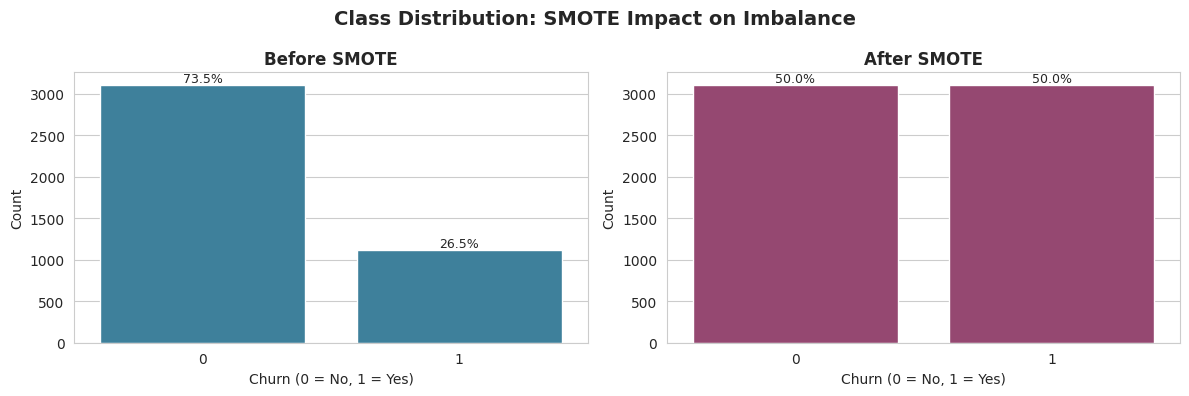

/tmp/ipykernel_3090/4185864567.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_to_plot, labels=model_names, patch_artist=True)


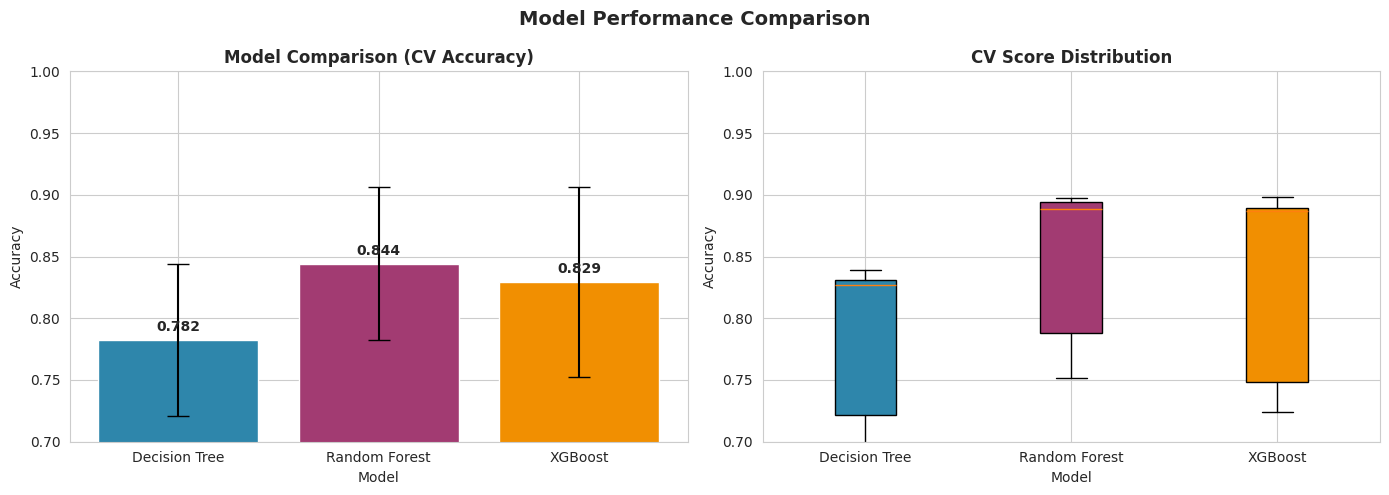

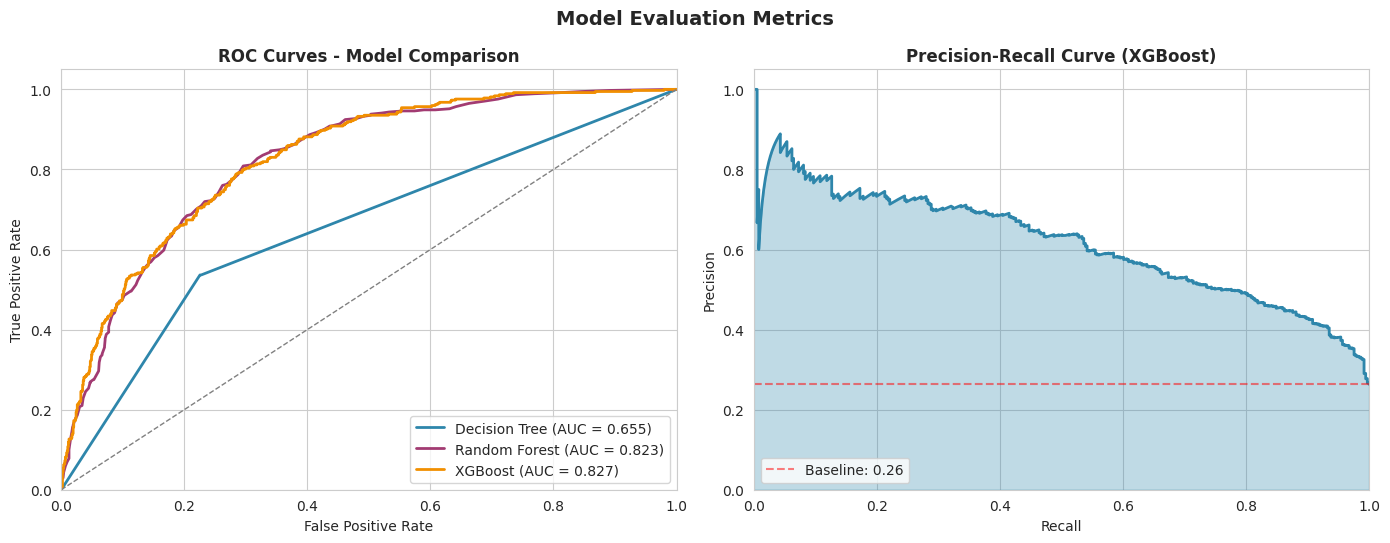

/tmp/ipykernel_3090/4185864567.py:146: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_features['Readable'] = top_features['Feature'].map(lambda x: feature_labels.get(x, x))


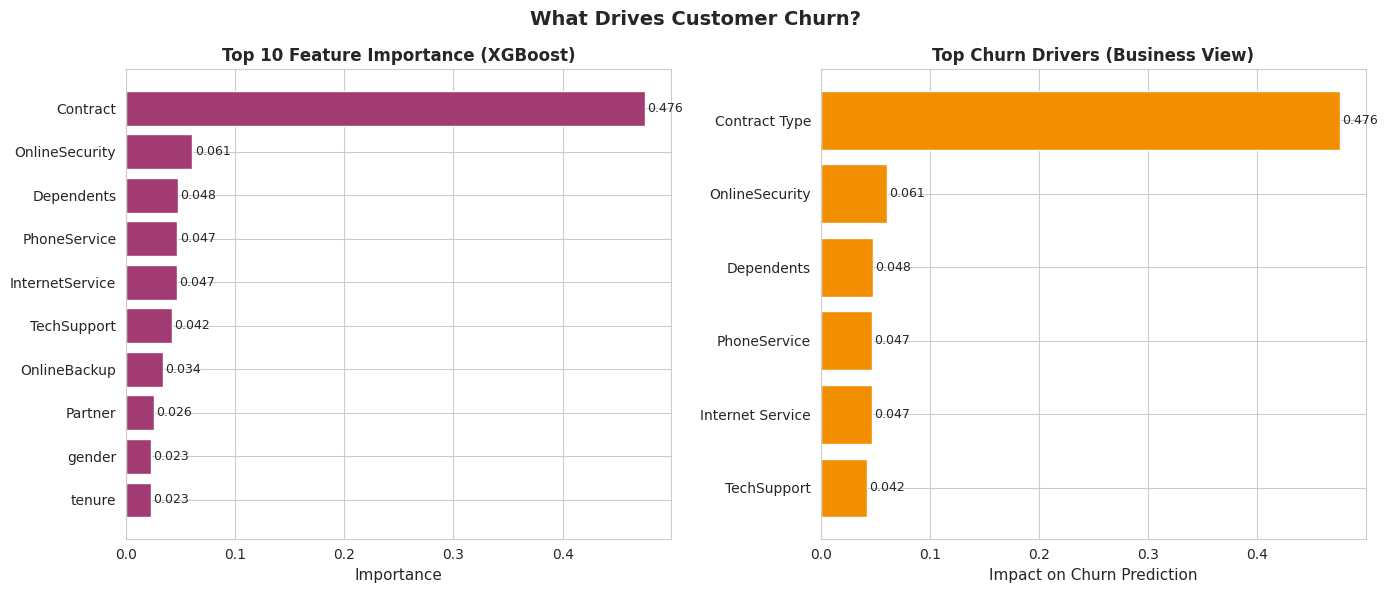

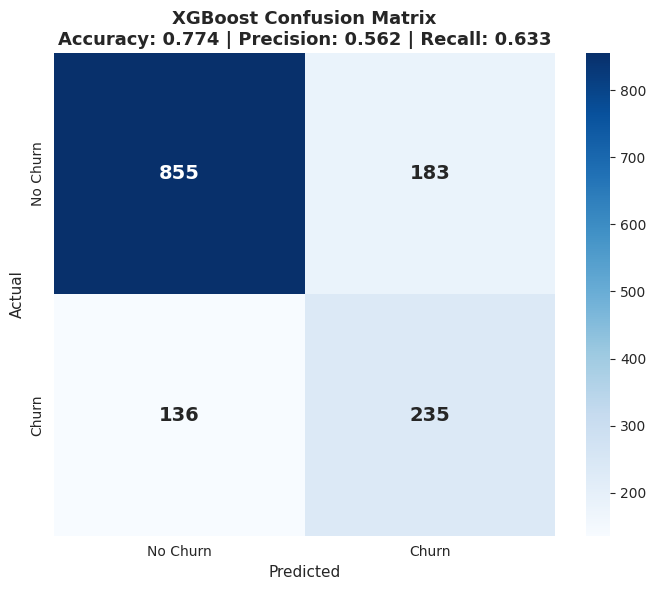

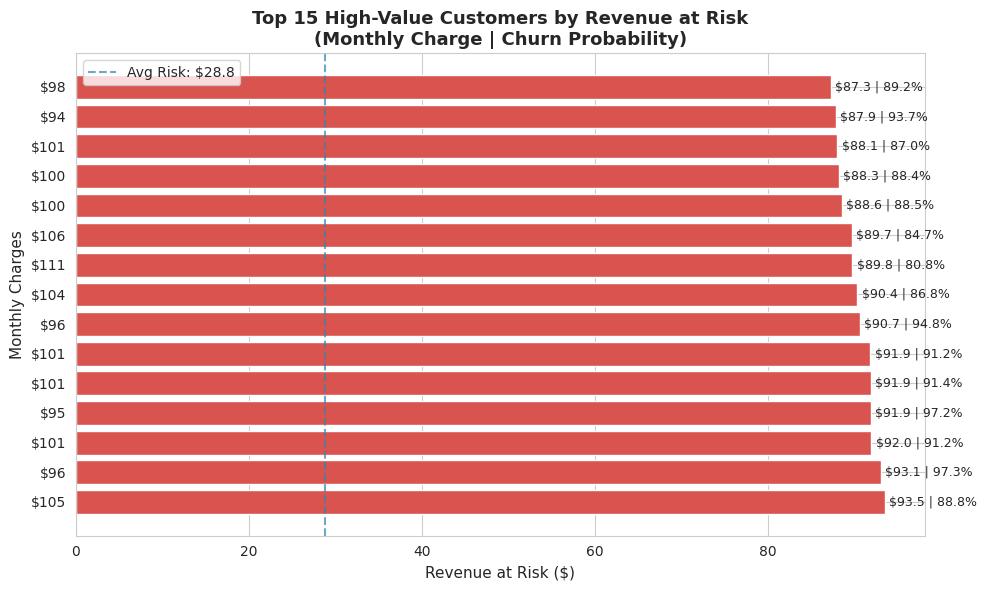


REVENUE AT RISK SUMMARY
Total Monthly Revenue at Risk: $40,630.85
Average Risk per Customer: $28.84
Top 5 Customers represent: $462.42 risk
Top 15 Customers represent: 15 customers contribute $1,355.06 risk


In [ ]:
# Create subplot with before and after SMOTE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Before SMOTE
sns.countplot(x=y_train, ax=ax1, color='#2E86AB')
ax1.set_title("Before SMOTE", fontsize=12, fontweight='bold')
ax1.set_xlabel("Churn (0 = No, 1 = Yes)")
ax1.set_ylabel("Count")

# Add percentage annotations on Before SMOTE
total_before = len(y_train)
for p in ax1.patches:
    percentage = f'{100 * p.get_height() / total_before:.1f}%'
    ax1.annotate(percentage, (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=9)

# After SMOTE
sns.countplot(x=y_train_smote, ax=ax2, color='#A23B72')
ax2.set_title("After SMOTE", fontsize=12, fontweight='bold')
ax2.set_xlabel("Churn (0 = No, 1 = Yes)")
ax2.set_ylabel("Count")

# Add percentage annotations on After SMOTE
total_after = len(y_train_smote)
for p in ax2.patches:
    percentage = f'{100 * p.get_height() / total_after:.1f}%'
    ax2.annotate(percentage, (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=9)

fig.suptitle("Class Distribution: SMOTE Impact on Imbalance", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Create subplot for model comparison and CV distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Model Comparison Bar Chart
model_names = list(cv_results.keys())
mean_scores = [np.mean(scores) for scores in cv_results.values()]
std_scores = [np.std(scores) for scores in cv_results.values()]

bars = ax1.bar(model_names, mean_scores, yerr=std_scores, capsize=8,
               color=['#2E86AB', '#A23B72', '#F18F01'])
ax1.set_ylim(0.7, 1.0)
ax1.set_title("Model Comparison (CV Accuracy)", fontsize=12, fontweight='bold')
ax1.set_ylabel("Accuracy")
ax1.set_xlabel("Model")

# Add value labels on bars
for bar, score in zip(bars, mean_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{score:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Subplot 2: Cross-Validation Boxplot
data_to_plot = [cv_results[name] for name in model_names]
bp = ax2.boxplot(data_to_plot, labels=model_names, patch_artist=True)
for patch, color in zip(bp['boxes'], ['#2E86AB', '#A23B72', '#F18F01']):
    patch.set_facecolor(color)
ax2.set_title("CV Score Distribution", fontsize=12, fontweight='bold')
ax2.set_ylabel("Accuracy")
ax2.set_xlabel("Model")
ax2.set_ylim(0.7, 1.0)

fig.suptitle("Model Performance Comparison", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# Create subplot for ROC and Precision-Recall
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Subplot 1: ROC Curves for All Models
colors = ['#2E86AB', '#A23B72', '#F18F01']
for (name, model), color in zip(models.items(), colors):
    if name == "XGBoost":
        model.fit(X_train_smote, y_train_smote)
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        model.fit(X_train_smote, y_train_smote)
        y_proba = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

ax1.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_title("ROC Curves - Model Comparison", fontsize=12, fontweight='bold')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.legend(loc="lower right")

# Subplot 2: Precision-Recall Curve (XGBoost)
y_proba_xgb = xgb_best.predict_proba(X_test)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, y_proba_xgb)

ax2.plot(recall, precision, color='#2E86AB', lw=2)
ax2.fill_between(recall, precision, alpha=0.3, color='#2E86AB')
ax2.set_title("Precision-Recall Curve (XGBoost)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])

# Add baseline (random classifier)
ax2.axhline(y=len(y_test[y_test==1])/len(y_test), color='red', linestyle='--',
            alpha=0.5, label=f'Baseline: {len(y_test[y_test==1])/len(y_test):.2f}')
ax2.legend(loc="lower left")

fig.suptitle("Model Evaluation Metrics", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Create subplot for feature importance and churn drivers
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Top 10 Feature Importance (XGBoost)
feature_importance = xgb_best.feature_importances_
feature_names = X.columns
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
feature_df = feature_df.sort_values('Importance', ascending=False).head(10)

ax1.barh(feature_df['Feature'], feature_df['Importance'], color='#A23B72')
ax1.set_xlabel("Importance", fontsize=11)
ax1.set_title("Top 10 Feature Importance (XGBoost)", fontsize=12, fontweight='bold')
ax1.invert_yaxis()

# Add value labels
for i, (idx, row) in enumerate(feature_df.iterrows()):
    ax1.text(row['Importance'] + 0.002, i, f'{row["Importance"]:.3f}',
             va='center', fontsize=9)

# Subplot 2: Top Churn Drivers (Readable Format)
top_features = feature_df.head(6)

feature_labels = {
    'Contract': 'Contract Type',
    'tenure': 'Tenure (months)',
    'MonthlyCharges': 'Monthly Charges',
    'TotalCharges': 'Total Charges',
    'InternetService': 'Internet Service',
    'PaymentMethod': 'Payment Method'
}

top_features['Readable'] = top_features['Feature'].map(lambda x: feature_labels.get(x, x))

ax2.barh(top_features['Readable'], top_features['Importance'], color='#F18F01')
ax2.set_xlabel("Impact on Churn Prediction", fontsize=11)
ax2.set_title("Top Churn Drivers (Business View)", fontsize=12, fontweight='bold')
ax2.invert_yaxis()

# Add value labels
for i, (idx, row) in enumerate(top_features.iterrows()):
    ax2.text(row['Importance'] + 0.002, i, f'{row["Importance"]:.3f}',
             va='center', fontsize=9)

fig.suptitle("What Drives Customer Churn?", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Confusion Matrix as standalone visual
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            annot_kws={'size': 14, 'weight': 'bold'})

# Add custom text for metrics
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0

plt.title(f"XGBoost Confusion Matrix\nAccuracy: {accuracy:.3f} | Precision: {precision:.3f} | Recall: {recall:.3f}",
          fontsize=13, fontweight='bold')
plt.ylabel("Actual", fontsize=11)
plt.xlabel("Predicted", fontsize=11)
plt.tight_layout()
plt.show()

# Revenue at Risk as standalone visual
plt.figure(figsize=(10, 6))

top_risk = results_df.nlargest(15, 'Revenue_At_Risk')

# Create horizontal bar chart
bars = plt.barh(range(len(top_risk)), top_risk['Revenue_At_Risk'], color='#d9534f')

# Customize y-axis labels (show Monthly Charges)
plt.yticks(range(len(top_risk)), [f"${x:.0f}" for x in top_risk['MonthlyCharges']])

# Add value labels on bars
for i, (idx, row) in enumerate(top_risk.iterrows()):
    plt.text(row['Revenue_At_Risk'] + 0.5, i,
             f"${row['Revenue_At_Risk']:.1f} | {row['Churn_Probability']*100:.1f}%",
             va='center', fontsize=9)

plt.xlabel("Revenue at Risk ($)", fontsize=11)
plt.ylabel("Monthly Charges", fontsize=11)
plt.title("Top 15 High-Value Customers by Revenue at Risk\n(Monthly Charge | Churn Probability)",
          fontsize=13, fontweight='bold')

# Add a vertical line for average risk
avg_risk = results_df['Revenue_At_Risk'].mean()
plt.axvline(x=avg_risk, color='#2E86AB', linestyle='--', alpha=0.7,
            label=f'Avg Risk: ${avg_risk:.1f}')
plt.legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*50)
print("REVENUE AT RISK SUMMARY")
print("="*50)
print(f"Total Monthly Revenue at Risk: ${results_df['Revenue_At_Risk'].sum():,.2f}")
print(f"Average Risk per Customer: ${results_df['Revenue_At_Risk'].mean():.2f}")
print(f"Top 5 Customers represent: ${top_risk.head(5)['Revenue_At_Risk'].sum():,.2f} risk")
print(f"Top 15 Customers represent: {len(top_risk)} customers contribute ${top_risk['Revenue_At_Risk'].sum():,.2f} risk")
print("="*50)
